In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df=pd.read_csv(r"C:\Users\Sumit's\OneDrive\Desktop\M.L_01\venv\cibil_nn.csv")
df = df.drop(columns=['Unnamed: 0'])

In [3]:
df.columns = df.columns.str.lower().str.strip()
print(df.columns)

Index(['prospectid', 'total_tl', 'tot_closed_tl', 'tot_active_tl',
       'total_tl_opened_l6m', 'tot_tl_closed_l6m', 'pct_tl_open_l6m',
       'pct_tl_closed_l6m', 'pct_active_tl', 'pct_closed_tl',
       'total_tl_opened_l12m', 'tot_tl_closed_l12m', 'pct_tl_open_l12m',
       'pct_tl_closed_l12m', 'tot_missed_pmnt', 'auto_tl', 'cc_tl',
       'consumer_tl', 'gold_tl', 'home_tl', 'pl_tl', 'secured_tl',
       'unsecured_tl', 'other_tl', 'age_oldest_tl', 'age_newest_tl',
       'time_since_recent_payment', 'time_since_first_deliquency',
       'time_since_recent_deliquency', 'num_times_delinquent',
       'max_delinquency_level', 'max_recent_level_of_deliq', 'num_deliq_6mts',
       'num_deliq_12mts', 'num_deliq_6_12mts', 'max_deliq_6mts',
       'max_deliq_12mts', 'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std',
       'num_std_6mts', 'num_std_12mts', 'num_sub', 'num_sub_6mts',
       'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_dbt_12mts', 'num_lss',
       'num_lss_6mts', 'n

In [4]:
print(df.duplicated().sum())

0


In [9]:
numeric_cols = df.select_dtypes(include=['number']).columns

print("Numeric Columns:",)
print(numeric_cols)

Numeric Columns:
Index(['prospectid', 'total_tl', 'tot_closed_tl', 'tot_active_tl',
       'total_tl_opened_l6m', 'tot_tl_closed_l6m', 'pct_tl_open_l6m',
       'pct_tl_closed_l6m', 'pct_active_tl', 'pct_closed_tl',
       'total_tl_opened_l12m', 'tot_tl_closed_l12m', 'pct_tl_open_l12m',
       'pct_tl_closed_l12m', 'tot_missed_pmnt', 'auto_tl', 'cc_tl',
       'consumer_tl', 'gold_tl', 'home_tl', 'pl_tl', 'secured_tl',
       'unsecured_tl', 'other_tl', 'age_oldest_tl', 'age_newest_tl',
       'time_since_recent_payment', 'time_since_first_deliquency',
       'time_since_recent_deliquency', 'num_times_delinquent',
       'max_delinquency_level', 'max_recent_level_of_deliq', 'num_deliq_6mts',
       'num_deliq_12mts', 'num_deliq_6_12mts', 'max_deliq_6mts',
       'max_deliq_12mts', 'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std',
       'num_std_6mts', 'num_std_12mts', 'num_sub', 'num_sub_6mts',
       'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_dbt_12mts', 'num_lss',
       '

In [7]:
categorical_cols = df.select_dtypes(exclude=['number']).columns

In [10]:
print("\nCategorical Columns:")
print(categorical_cols)


Categorical Columns:
Index(['maritalstatus', 'education', 'gender', 'last_prod_enq2',
       'first_prod_enq2', 'approved_flag'],
      dtype='object')


In [20]:
print(df['approved_flag'].unique())

['P4' 'P2' 'P3' 'P1']


In [21]:
print(df.columns)

Index(['prospectid', 'total_tl', 'tot_closed_tl', 'tot_active_tl',
       'total_tl_opened_l6m', 'tot_tl_closed_l6m', 'pct_tl_open_l6m',
       'pct_tl_closed_l6m', 'pct_active_tl', 'pct_closed_tl',
       'total_tl_opened_l12m', 'tot_tl_closed_l12m', 'pct_tl_open_l12m',
       'pct_tl_closed_l12m', 'tot_missed_pmnt', 'auto_tl', 'cc_tl',
       'consumer_tl', 'gold_tl', 'home_tl', 'pl_tl', 'secured_tl',
       'unsecured_tl', 'other_tl', 'age_oldest_tl', 'age_newest_tl',
       'time_since_recent_payment', 'time_since_first_deliquency',
       'time_since_recent_deliquency', 'num_times_delinquent',
       'max_delinquency_level', 'max_recent_level_of_deliq', 'num_deliq_6mts',
       'num_deliq_12mts', 'num_deliq_6_12mts', 'max_deliq_6mts',
       'max_deliq_12mts', 'num_times_30p_dpd', 'num_times_60p_dpd', 'num_std',
       'num_std_6mts', 'num_std_12mts', 'num_sub', 'num_sub_6mts',
       'num_sub_12mts', 'num_dbt', 'num_dbt_6mts', 'num_dbt_12mts', 'num_lss',
       'num_lss_6mts', 'n

In [22]:
# Analysis of target variable

counts = df["approved_flag"].value_counts()

print("Count of each class:")
print(counts)

print("\nPercentage:")
print(df["approved_flag"].value_counts(normalize=True) * 100)

Count of each class:
approved_flag
P2    266
P4    122
P1     99
P3     98
Name: count, dtype: int64

Percentage:
approved_flag
P2    45.470085
P4    20.854701
P1    16.923077
P3    16.752137
Name: proportion, dtype: float64


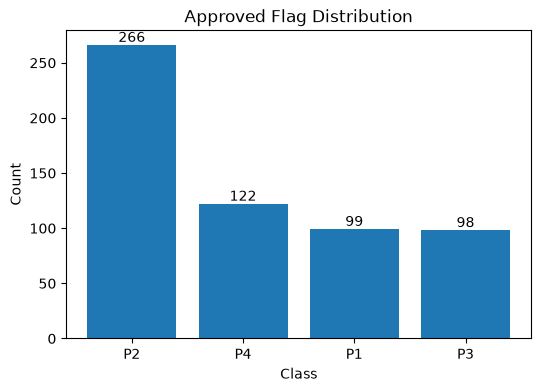

In [27]:
counts = df["approved_flag"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(counts.index, counts.values)

for i, v in enumerate(counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.title("Approved Flag Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [24]:
"approved_flag" in df.columns

True

In [11]:

df['credit_score'].describe()

count    585.000000
mean     677.547009
std       28.276308
min      561.000000
25%      662.000000
50%      676.000000
75%      694.000000
max      795.000000
Name: credit_score, dtype: float64

In [12]:
df['credit_score'].isnull().sum()

np.int64(0)

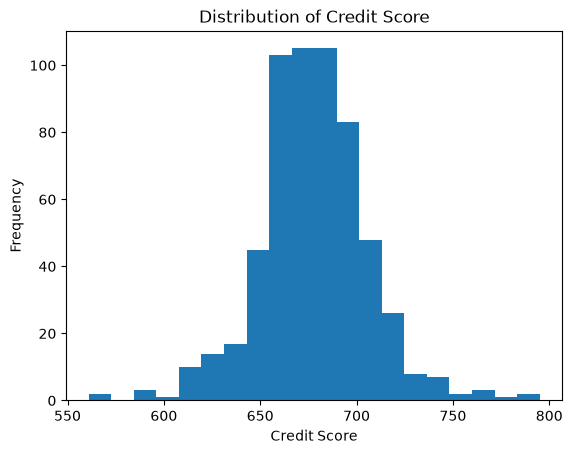

In [13]:
import matplotlib.pyplot as plt

plt.hist(df['credit_score'], bins=20)
plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

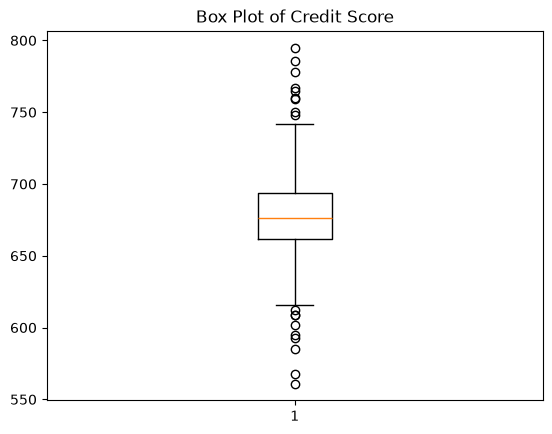

In [14]:
#Check outliers

plt.boxplot(df['credit_score'])
plt.title("Box Plot of Credit Score")
plt.show()

In [15]:
#check skewness

df['credit_score'].skew()

np.float64(0.09706214345709051)

In [16]:
# check correlation
correlation = df.corr(numeric_only=True)

print(correlation['credit_score'].sort_values(ascending=False))

credit_score     1.000000
num_std_12mts    0.591090
num_std          0.581248
age_oldest_tl    0.574445
num_std_6mts     0.566281
                   ...   
num_lss               NaN
num_lss_6mts          NaN
num_lss_12mts         NaN
cc_flag               NaN
pl_flag               NaN
Name: credit_score, Length: 81, dtype: float64


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
numeric_df = df.select_dtypes(include=['number'])
corr_matrix = numeric_df.corr()

print(corr_matrix)

                          prospectid  total_tl  tot_closed_tl  tot_active_tl  \
prospectid                  1.000000 -0.030565      -0.038918       0.008488   
total_tl                   -0.030565  1.000000       0.964254       0.628986   
tot_closed_tl              -0.038918  0.964254       1.000000       0.400502   
tot_active_tl               0.008488  0.628986       0.400502       1.000000   
total_tl_opened_l6m         0.049455  0.362274       0.204001       0.654226   
...                              ...       ...            ...            ...   
pct_cc_enq_l6m_of_ever      0.004993  0.017879       0.001800       0.056544   
max_unsec_exposure_inpct    0.068106 -0.019769      -0.017317      -0.017553   
hl_flag                     0.022505  0.424487       0.417697       0.242399   
gl_flag                    -0.021816  0.128035       0.085858       0.190845   
credit_score               -0.035597  0.113683       0.123746       0.030058   

                          total_tl_open

In [20]:
corr_target = numeric_df.corr()['credit_score'].sort_values(ascending=False)

print(corr_target)

credit_score     1.000000
num_std_12mts    0.591090
num_std          0.581248
age_oldest_tl    0.574445
num_std_6mts     0.566281
                   ...   
num_lss               NaN
num_lss_6mts          NaN
num_lss_12mts         NaN
cc_flag               NaN
pl_flag               NaN
Name: credit_score, Length: 81, dtype: float64


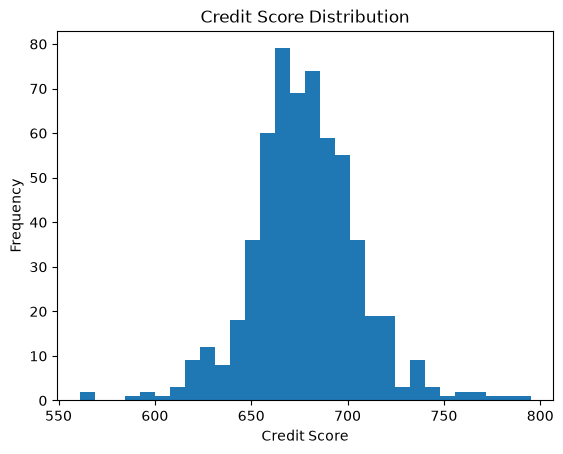

In [22]:
plt.hist(

    df["credit_score"],

    bins=30

)

plt.xlabel("Credit Score")

plt.ylabel("Frequency")

plt.title("Credit Score Distribution")

plt.show()